In [1]:
!pip -q install ROOT

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.9/247.9 MB 6.0 MB/s eta 0:00:00


In [2]:
import ROOT

print("ROOT version:", ROOT.gROOT.GetVersion())

ROOT version: 6.40.00


/usr/local/lib/python3.13/dist-packages/ROOT/__init__.py:222: UserWarning: 
This distribution of ROOT is in alpha stage. Feedback is welcome and appreciated. Feel free to reach out to the user forum for questions and general feedback at https://root-forum.cern.ch or to submit an issue at https://github.com/root-project/root/issues. Do not rely on this distribution for production purposes.

  warnings.warn(


In [8]:
import ROOT

file_path = "/content/mvmelst_008_e10.root"

root_file = ROOT.TFile.Open(file_path, "READ")

if not root_file or root_file.IsZombie():
    raise OSError(f"Could not open: {file_path}")

print("Opened successfully:", root_file.GetName())

print("--------------------------------------------------------------------")


for key in root_file.GetListOfKeys():
    print(
        "Name:", key.GetName(),
        "| Type:", key.GetClassName()
    )

Opened successfully: /content/mvmelst_008_e10.root
--------------------------------------------------------------------
Name: h_e10 | Type: TH1F


In [9]:
hist = root_file.Get("h_e10")

if not hist:
    raise KeyError("Histogram 'h_e10' was not found")

print("Name:", hist.GetName())
print("Title:", hist.GetTitle())
print("Number of bins:", hist.GetNbinsX())
print("Entries:", hist.GetEntries())
print("Mean:", hist.GetMean())
print("Standard deviation:", hist.GetStdDev())


Name: h_e10
Title: mvmelst_008 - Channel 10
Number of bins: 8192
Entries: 8192.0
Mean: 2097.945731636634
Standard deviation: 2235.2514681696352


Warning in <TCanvas::Constructor>: Deleting canvas with same name: canvas2


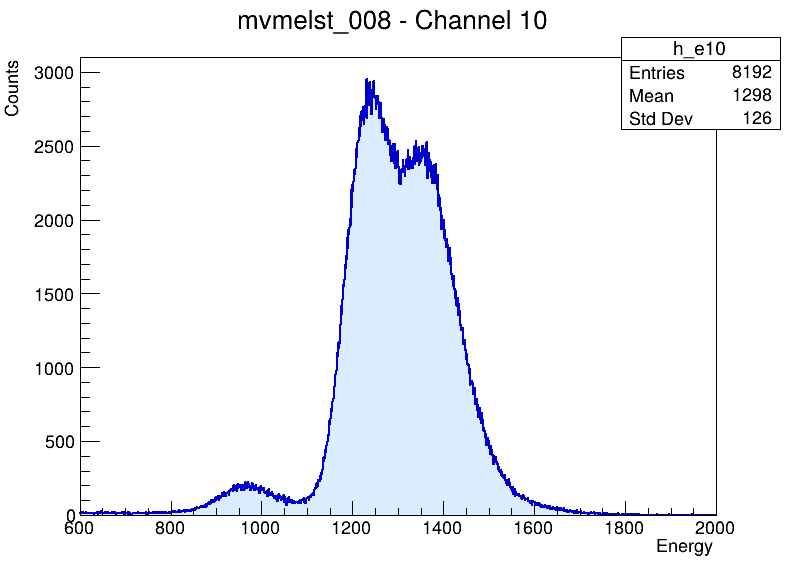

In [12]:
canvas = ROOT.TCanvas("canvas2", "h_e10", 800, 600)

hist.GetXaxis().SetRangeUser(600, 2000)
hist.GetXaxis().SetTitle("Energy")
hist.GetYaxis().SetTitle("Counts")

hist.SetLineColor(ROOT.kBlue + 1)
hist.SetLineWidth(2)

hist.Draw("HIST")
canvas.Draw()

# Using three gaussian functions and the background


Small Gaussian:
  Mean      = 968.17 ± 0.72
  Sigma     = 55.25 ± 1.03

Fit quality:
  Chi-square     = 1040.83
  NDF            = 838
  Chi-square/NDF = 1.24
  Fit status     = 0
****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =      1040.83
NDf                       =          838
Edm                       =  1.49795e-07
NCalls                    =          817
Small amplitude           =      158.572   +/-   2.41618      	 (limited)
Small mean                =      968.169   +/-   0.722758     	 (limited)
Small sigma               =      55.2461   +/-   1.0299       	 (limited)
Peak 1 amplitude          =      1987.83   +/-   19.6914      	 (limited)
Peak 1 mean               =      1223.34   +/-   0.291229     	 (limited)
Peak 1 sigma              =      42.0074   +/-   0.255114     	 (limited)
Peak 2 amplitude          =      2336.59   +/-   7.18935      	 (limited)
Peak 2 mean               =      1348.06   +/-   0.676896     	 (l

Warning in <TCanvas::Constructor>: Deleting canvas with same name: canvas_three_gaussian_pol2


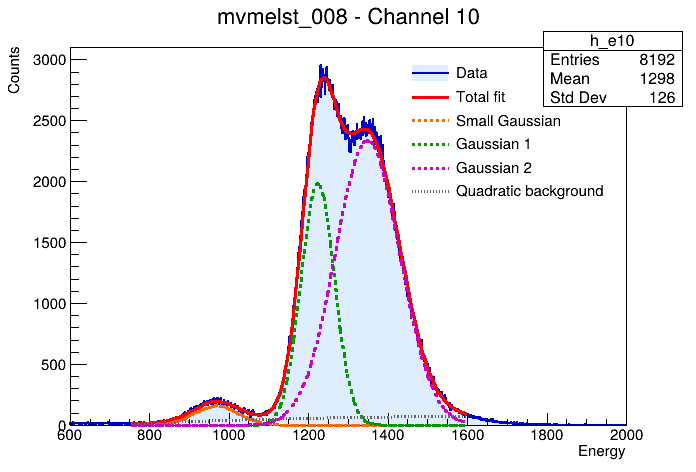

In [72]:


# ------------------------------------------------------------
# Fit settings
# ------------------------------------------------------------
fit_min = 750
fit_max = 1600

# ------------------------------------------------------------
# Model:
#   Small Gaussian + Gaussian 1 + Gaussian 2 + pol2 background
#
# [0], [1], [2]    = small peak: amplitude, mean, sigma
# [3], [4], [5]    = peak 1: amplitude, mean, sigma
# [6], [7], [8]    = peak 2: amplitude, mean, sigma
# [9], [10], [11]  = background: p0, p1, p2
# ------------------------------------------------------------
fit_func = ROOT.TF1(
    "three_gaussian_pol2_fit",
    "gaus(0) + gaus(3) + gaus(6) + pol2(9)",
    fit_min,
    fit_max
)

# Initial parameter estimates
initial_parameters = [
    200, 980, 55,       # Small peak
    2000, 1240, 45,     # Large peak 1
    2300, 1360, 65,     # Large peak 2
    10, 0, 0            # Quadratic background
]

# Set parameters individually to avoid PyROOT's argument limit
for index, value in enumerate(initial_parameters):
    fit_func.SetParameter(index, value)

# Give the parameters descriptive names
parameter_names = [
    "Small amplitude",
    "Small mean",
    "Small sigma",
    "Peak 1 amplitude",
    "Peak 1 mean",
    "Peak 1 sigma",
    "Peak 2 amplitude",
    "Peak 2 mean",
    "Peak 2 sigma",
    "Background p0",
    "Background p1",
    "Background p2"
]

for index, name in enumerate(parameter_names):
    fit_func.SetParName(index, name)

# ------------------------------------------------------------
# Parameter constraints
# ------------------------------------------------------------

# Small peak
fit_func.SetParLimits(0, 0, 1000)
fit_func.SetParLimits(1, 900, 1050)
fit_func.SetParLimits(2, 10, 120)

# Large peak 1
fit_func.SetParLimits(3, 0, 5000)
fit_func.SetParLimits(4, 1180, 1300)
fit_func.SetParLimits(5, 5, 150)

# Large peak 2
fit_func.SetParLimits(6, 0, 5000)
fit_func.SetParLimits(7, 1300, 1450)
fit_func.SetParLimits(8, 5, 150)

# ------------------------------------------------------------
# Perform the fit
#
# R = use the specified fit range
# S = return the fit-result object
# ------------------------------------------------------------
fit_result = hist.Fit(fit_func, "RS")

# ------------------------------------------------------------
# Create individual fitted components
# ------------------------------------------------------------

# Small Gaussian
small_gaussian = ROOT.TF1(
    "small_gaussian_component",
    "gaus",
    fit_min,
    fit_max
)

small_gaussian.SetParameters(
    fit_func.GetParameter(0),
    fit_func.GetParameter(1),
    fit_func.GetParameter(2)
)

small_gaussian.SetLineColor(ROOT.kOrange + 7)
small_gaussian.SetLineStyle(2)
small_gaussian.SetLineWidth(3)

# Large Gaussian 1
gaussian1 = ROOT.TF1(
    "large_gaussian1_component",
    "gaus",
    fit_min,
    fit_max
)

gaussian1.SetParameters(
    fit_func.GetParameter(3),
    fit_func.GetParameter(4),
    fit_func.GetParameter(5)
)

gaussian1.SetLineColor(ROOT.kGreen + 2)
gaussian1.SetLineStyle(2)
gaussian1.SetLineWidth(3)

# Large Gaussian 2
gaussian2 = ROOT.TF1(
    "large_gaussian2_component",
    "gaus",
    fit_min,
    fit_max
)

gaussian2.SetParameters(
    fit_func.GetParameter(6),
    fit_func.GetParameter(7),
    fit_func.GetParameter(8)
)

gaussian2.SetLineColor(ROOT.kMagenta + 1)
gaussian2.SetLineStyle(2)
gaussian2.SetLineWidth(3)

# Quadratic background
background = ROOT.TF1(
    "pol2_background_component",
    "pol2",
    fit_min,
    fit_max
)

background.SetParameters(
    fit_func.GetParameter(9),
    fit_func.GetParameter(10),
    fit_func.GetParameter(11)
)

background.SetLineColor(ROOT.kGray + 2)
background.SetLineStyle(3)
background.SetLineWidth(3)

# ------------------------------------------------------------
# Draw histogram and fitted components
# ------------------------------------------------------------
canvas_fit = ROOT.TCanvas(
    "canvas_three_gaussian_pol2",
    "Three Gaussians with quadratic background",
    700,
    500
)

hist.SetLineColor(ROOT.kBlue + 1)
hist.SetLineWidth(2)
hist.SetFillColorAlpha(ROOT.kAzure - 9, 0.30)

hist.GetXaxis().SetRangeUser(600, 2000)
hist.GetXaxis().SetTitle("Energy")
hist.GetYaxis().SetTitle("Counts")
hist.Draw("HIST")

# Total fitted model
fit_func.SetLineColor(ROOT.kRed)
fit_func.SetLineWidth(3)
fit_func.Draw("SAME")

# Individual fitted components
small_gaussian.Draw("SAME")
gaussian1.Draw("SAME")
gaussian2.Draw("SAME")
background.Draw("SAME")

# Legend
legend = ROOT.TLegend(0.58, 0.57, 0.88, 0.87)
legend.SetBorderSize(0)
legend.SetFillStyle(0)

legend.AddEntry(hist, "Data", "lf")
legend.AddEntry(fit_func, "Total fit", "l")
legend.AddEntry(small_gaussian, "Small Gaussian", "l")
legend.AddEntry(gaussian1, "Gaussian 1", "l")
legend.AddEntry(gaussian2, "Gaussian 2", "l")
legend.AddEntry(background, "Quadratic background", "l")

legend.Draw()
canvas_fit.Draw()

# ------------------------------------------------------------
# Extract fitted parameters
# ------------------------------------------------------------

# Small peak
small_amplitude = fit_func.GetParameter(0)
small_amplitude_error = fit_func.GetParError(0)

small_mean = fit_func.GetParameter(1)
small_mean_error = fit_func.GetParError(1)

small_sigma = fit_func.GetParameter(2)
small_sigma_error = fit_func.GetParError(2)


# Fit quality
chi_square = fit_func.GetChisquare()
ndf = fit_func.GetNDF()

reduced_chi_square = (
    chi_square / ndf
    if ndf > 0
    else float("nan")
)

# ------------------------------------------------------------
# Print results for dedicated peak
# ------------------------------------------------------------

print("\nSmall Gaussian:")
print(
    f"  Mean      = {small_mean:.2f} "
    f"± {small_mean_error:.2f}"
)
print(
    f"  Sigma     = {small_sigma:.2f} "
    f"± {small_sigma_error:.2f}"
)

print("\nFit quality:")
print(f"  Chi-square     = {chi_square:.2f}")
print(f"  NDF            = {ndf}")
print(f"  Chi-square/NDF = {reduced_chi_square:.2f}")
print(f"  Fit status     = {int(fit_result)}")

# Warn if the fit did not converge
if int(fit_result) != 0:
    print(
        "\nWarning: the fit did not converge successfully. "
        "Try adjusting the initial estimates or parameter limits."
    )

# Print the information for small peak (peak near to 1000)

In [73]:
import math

# ------------------------------------------------------------
# Count events in the small peak within mean ± 3 sigma
# ------------------------------------------------------------
small_lower_limit = small_mean - 3.0 * small_sigma
small_upper_limit = small_mean + 3.0 * small_sigma

# Histogram bin width, assuming uniform binning
mean_bin = hist.GetXaxis().FindBin(small_mean)
bin_width = hist.GetXaxis().GetBinWidth(mean_bin)

# Integral of the fitted Gaussian between mean - 3 sigma
# and mean + 3 sigma.
#
# Division by bin width converts the TF1 area into histogram counts.
small_peak_count = (
    small_amplitude
    * small_sigma
    * math.sqrt(2.0 * math.pi)
    * math.erf(3.0 / math.sqrt(2.0))
    / bin_width
)

# Total fitted Gaussian count over the full range (-infinity, +infinity)
small_peak_total_count = (
    small_amplitude
    * small_sigma
    * math.sqrt(2.0 * math.pi)
    / bin_width
)

# Fraction of a Gaussian inside ±3 sigma
fraction_inside_3sigma = math.erf(3.0 / math.sqrt(2.0))

# Observed histogram counts in the same interval.
# This includes signal and background.
first_bin = hist.GetXaxis().FindBin(small_lower_limit)
last_bin = hist.GetXaxis().FindBin(small_upper_limit)

observed_count = hist.Integral(first_bin, last_bin)


print("\nSmall-peak counts:")
print(
    f"  Integration interval = "
    f"[{small_lower_limit:.2f}, {small_upper_limit:.2f}]"
)
print(f"  Histogram bin width  = {bin_width:.4g}")
print(f"  Gaussian count ±3σ   = {small_peak_count:.2f}")
print(f"  Full Gaussian count  = {small_peak_total_count:.2f}")
print(f"  Observed bin count   = {observed_count:.2f}")
print(
    f"  Gaussian fraction inside ±3σ = "
    f"{100.0 * fraction_inside_3sigma:.3f}%"
)



Small-peak counts:
  Integration interval = [802.43, 1133.91]
  Histogram bin width  = 0.9999
  Gaussian count ±3σ   = 21902.69
  Full Gaussian count  = 21961.98
  Observed bin count   = 39864.00
  Gaussian fraction inside ±3σ = 99.730%


# Using crystal Ball Function (dedicated to the necessary peak only)

****************************************
         Invalid FitResult  (status = 2 )
****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =      387.316
NDf                       =          360
Edm                       =  1.05901e-06
NCalls                    =         1615
Signal amplitude          =      151.339   +/-   0            	 (limited)
Signal mean               =      966.079   +/-   0            	 (limited)
Signal sigma              =      52.7421   +/-   0            	 (limited)
Tail alpha                =      4.20864   +/-   0            	 (limited)
Tail n                    =      8.84487   +/-   0            	 (limited)
Background at join        =       59.925   +/-   0            	 (limited)
Left slope                =     0.159185   +/-   0           
Right slope               =   -0.0457703   +/-   0           
Right quadratic           =    0.0302698   +/-   0           
Join point                =         1060   +/-   0  

Warning in <Fit>: Abnormal termination of minimization.
Warning in <TCanvas::Constructor>: Deleting canvas with same name: canvas_small_peak_free_join



========== SMALL-PEAK FIT RESULTS ==========

Crystal Ball signal:
  Amplitude = 151.339 ± 0.000
  Mean      = 966.079 ± 0.000
  Sigma     = 52.742 ± 0.000
  Alpha     = 4.209 ± 0.000
  Tail n    = 8.845 ± 0.000

Piecewise background:
  Fitted join point = 1060.000 ± 0.000
  Background at join = 59.925 ± 0
  Left slope         = 0.159185 ± 0
  Right slope        = -0.0457703 ± 0
  Right quadratic    = 0.0302698 ± 0

Counts within fitted mean ± 3 sigma:
  Interval                  = [807.853, 1120.000]
  Histogram bin width       = 0.999878
  Crystal Ball signal count = 19947.95
  Fitted background count   = 15744.02
  Total fitted count        = 35691.98
  Observed histogram count  = 36217.00

Fit quality:
  Chi-square     = 387.316
  NDF            = 360
  Chi-square/NDF = 1.076
  Fit status     = 2




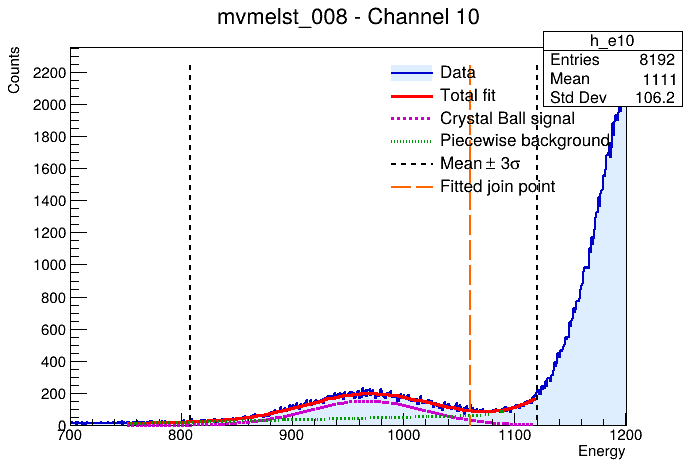

In [74]:
import ROOT
import math

# ------------------------------------------------------------
# Fit settings
# ------------------------------------------------------------
fit_min = 750.0
fit_max = 1120.0

# ------------------------------------------------------------
# Right-tailed Crystal Ball signal
#
# par[0] = amplitude
# par[1] = mean
# par[2] = sigma
# par[3] = alpha
# par[4] = tail exponent n
# ------------------------------------------------------------
def crystal_ball_right(x, par):
    amplitude = par[0]
    mean = par[1]
    sigma = abs(par[2])
    alpha = abs(par[3])
    tail_n = par[4]

    if sigma <= 0 or alpha <= 0 or tail_n <= 1:
        return 0.0

    t = (x[0] - mean) / sigma

    # Gaussian core
    if t <= alpha:
        return amplitude * math.exp(-0.5 * t * t)

    # Right-side power-law tail
    A = (
        (tail_n / alpha) ** tail_n
        * math.exp(-0.5 * alpha * alpha)
    )

    B = tail_n / alpha - alpha

    return amplitude * A * (B + t) ** (-tail_n)


# ------------------------------------------------------------
# Total model:
#
# Crystal Ball signal
# + pol1 background on the left
# + pol2 background on the right
#
# par[5] = background value at join
# par[6] = left slope
# par[7] = right slope
# par[8] = right quadratic coefficient
# par[9] = free join point
#
# The background is continuous at the join point.
# ------------------------------------------------------------
def total_model(x, par):
    signal = crystal_ball_right(x, par)

    background_at_join = par[5]
    left_slope = par[6]
    right_slope = par[7]
    right_quadratic = par[8]
    join_point = par[9]

    dx = x[0] - join_point

    if x[0] <= join_point:
        # Left-side pol1
        background = (
            background_at_join
            + left_slope * dx
        )
    else:
        # Right-side pol2
        background = (
            background_at_join
            + right_slope * dx
            + right_quadratic * dx * dx
        )

    return signal + background


# ------------------------------------------------------------
# Create total fit function
# ------------------------------------------------------------
fit_func = ROOT.TF1(
    "small_peak_crystal_ball_free_join",
    total_model,
    fit_min,
    fit_max,
    10
)

# Parameter names
parameter_names = [
    "Signal amplitude",      # 0
    "Signal mean",           # 1
    "Signal sigma",          # 2
    "Tail alpha",            # 3
    "Tail n",                # 4
    "Background at join",    # 5
    "Left slope",            # 6
    "Right slope",           # 7
    "Right quadratic",       # 8
    "Join point"             # 9
]

for index, name in enumerate(parameter_names):
    fit_func.SetParName(index, name)

# ------------------------------------------------------------
# Initial parameter estimates
# ------------------------------------------------------------
initial_parameters = [
    200.0,    # Signal amplitude
    980.0,    # Signal mean
    55.0,     # Signal sigma
    1.5,      # Alpha
    3.0,      # Tail exponent n
    10.0,     # Background value at join
    0.0,      # Left slope
    0.0,      # Right slope
    0.0,      # Right quadratic coefficient
    980.0     # Initial join point
]

for index, value in enumerate(initial_parameters):
    fit_func.SetParameter(index, value)

# ------------------------------------------------------------
# Parameter constraints
# ------------------------------------------------------------
fit_func.SetParLimits(0, 0.0, 1000.0)   # amplitude
fit_func.SetParLimits(1, 900.0, 1050.0) # mean
fit_func.SetParLimits(2, 5.0, 120.0)    # sigma
fit_func.SetParLimits(3, 0.3, 5.0)      # alpha
fit_func.SetParLimits(4, 1.01, 30.0)    # tail n

# Require nonnegative background value at the join
fit_func.SetParLimits(5, 0.0, 1000.0)

# Allow the fit to determine the join point within this range
fit_func.SetParLimits(9, 900.0, 1060.0)

# ------------------------------------------------------------
# Perform fit
#
# R = use specified fit range
# S = return fit-result object
# ------------------------------------------------------------
fit_result = hist.Fit(fit_func, "RS")

# ------------------------------------------------------------
# Extract fitted parameters
# ------------------------------------------------------------
amplitude = fit_func.GetParameter(0)
amplitude_error = fit_func.GetParError(0)

mean = fit_func.GetParameter(1)
mean_error = fit_func.GetParError(1)

sigma = abs(fit_func.GetParameter(2))
sigma_error = fit_func.GetParError(2)

alpha = fit_func.GetParameter(3)
alpha_error = fit_func.GetParError(3)

tail_n = fit_func.GetParameter(4)
tail_n_error = fit_func.GetParError(4)

background_at_join = fit_func.GetParameter(5)
background_at_join_error = fit_func.GetParError(5)

left_slope = fit_func.GetParameter(6)
left_slope_error = fit_func.GetParError(6)

right_slope = fit_func.GetParameter(7)
right_slope_error = fit_func.GetParError(7)

right_quadratic = fit_func.GetParameter(8)
right_quadratic_error = fit_func.GetParError(8)

fitted_join_point = fit_func.GetParameter(9)
fitted_join_error = fit_func.GetParError(9)

# ------------------------------------------------------------
# Create the signal-only component
# ------------------------------------------------------------
signal_func = ROOT.TF1(
    "small_peak_crystal_ball_signal_free_join",
    crystal_ball_right,
    fit_min,
    fit_max,
    5
)

for index in range(5):
    signal_func.SetParameter(
        index,
        fit_func.GetParameter(index)
    )

signal_func.SetLineColor(ROOT.kMagenta + 1)
signal_func.SetLineStyle(2)
signal_func.SetLineWidth(3)

# ------------------------------------------------------------
# Create the fitted background-only component
# ------------------------------------------------------------
def piecewise_background(x, par):
    background_at_join = par[0]
    left_slope = par[1]
    right_slope = par[2]
    right_quadratic = par[3]
    join_point = par[4]

    dx = x[0] - join_point

    if x[0] <= join_point:
        return background_at_join + left_slope * dx

    return (
        background_at_join
        + right_slope * dx
        + right_quadratic * dx * dx
    )


background_func = ROOT.TF1(
    "small_peak_background_free_join",
    piecewise_background,
    fit_min,
    fit_max,
    5
)

background_func.SetParameters(
    background_at_join,
    left_slope,
    right_slope,
    right_quadratic,
    fitted_join_point
)

background_func.SetLineColor(ROOT.kGreen + 2)
background_func.SetLineStyle(3)
background_func.SetLineWidth(3)

# ------------------------------------------------------------
# Signal integral within fitted mean ± 3 sigma
# ------------------------------------------------------------
lower_limit = mean - 3.0 * sigma
upper_limit = mean + 3.0 * sigma

# Keep integration within the fitted interval
integration_min = max(lower_limit, fit_min)
integration_max = min(upper_limit, fit_max)

# This conversion assumes uniform histogram bin widths
mean_bin = hist.GetXaxis().FindBin(mean)
bin_width = hist.GetXaxis().GetBinWidth(mean_bin)

# Crystal Ball signal only: polynomial background is excluded
signal_area_3sigma = signal_func.Integral(
    integration_min,
    integration_max
)

signal_count_3sigma = signal_area_3sigma / bin_width

# Fitted background within the same interval
background_area_3sigma = background_func.Integral(
    integration_min,
    integration_max
)

background_count_3sigma = (
    background_area_3sigma / bin_width
)

# Total fitted signal + background
total_fit_area_3sigma = fit_func.Integral(
    integration_min,
    integration_max
)

total_fit_count_3sigma = (
    total_fit_area_3sigma / bin_width
)

# Observed histogram count in the same interval
first_bin = hist.GetXaxis().FindBin(integration_min)
last_bin = hist.GetXaxis().FindBin(integration_max)

observed_count_3sigma = hist.Integral(
    first_bin,
    last_bin
)

# ------------------------------------------------------------
# Fit quality
# ------------------------------------------------------------
chi_square = fit_func.GetChisquare()
ndf = fit_func.GetNDF()

reduced_chi_square = (
    chi_square / ndf
    if ndf > 0
    else float("nan")
)

# ------------------------------------------------------------
# Draw
# ------------------------------------------------------------
canvas_small_peak = ROOT.TCanvas(
    "canvas_small_peak_free_join",
    "Small peak with free background join",
    700,
    500
)

hist.SetLineColor(ROOT.kBlue + 1)
hist.SetLineWidth(2)
hist.SetFillColorAlpha(ROOT.kAzure - 9, 0.30)

hist.GetXaxis().SetRangeUser(700, 1200)
hist.GetXaxis().SetTitle("Energy")
hist.GetYaxis().SetTitle("Counts")
hist.Draw("HIST")

# Total model
fit_func.SetLineColor(ROOT.kRed)
fit_func.SetLineWidth(3)
fit_func.Draw("SAME")

# Signal and background
signal_func.Draw("SAME")
background_func.Draw("SAME")

# Mean ±3 sigma lines
line_low = ROOT.TLine(
    integration_min,
    0,
    integration_min,
    hist.GetMaximum()
)

line_high = ROOT.TLine(
    integration_max,
    0,
    integration_max,
    hist.GetMaximum()
)

for line in [line_low, line_high]:
    line.SetLineColor(ROOT.kBlack)
    line.SetLineStyle(7)
    line.SetLineWidth(2)
    line.Draw("SAME")

# Fitted join-point line
join_line = ROOT.TLine(
    fitted_join_point,
    0,
    fitted_join_point,
    hist.GetMaximum()
)

join_line.SetLineColor(ROOT.kOrange + 7)
join_line.SetLineStyle(9)
join_line.SetLineWidth(2)
join_line.Draw("SAME")

# Legend
legend = ROOT.TLegend(0.55, 0.58, 0.88, 0.87)
legend.SetBorderSize(0)
legend.SetFillStyle(0)

legend.AddEntry(hist, "Data", "lf")
legend.AddEntry(fit_func, "Total fit", "l")
legend.AddEntry(signal_func, "Crystal Ball signal", "l")
legend.AddEntry(
    background_func,
    "Piecewise background",
    "l"
)
legend.AddEntry(line_low, "Mean #pm 3#sigma", "l")
legend.AddEntry(join_line, "Fitted join point", "l")

legend.Draw()
canvas_small_peak.Draw()

# ------------------------------------------------------------
# Print results
# ------------------------------------------------------------
print("\n========== SMALL-PEAK FIT RESULTS ==========")

print("\nCrystal Ball signal:")
print(
    f"  Amplitude = {amplitude:.3f} "
    f"± {amplitude_error:.3f}"
)
print(
    f"  Mean      = {mean:.3f} "
    f"± {mean_error:.3f}"
)
print(
    f"  Sigma     = {sigma:.3f} "
    f"± {sigma_error:.3f}"
)
print(
    f"  Alpha     = {alpha:.3f} "
    f"± {alpha_error:.3f}"
)
print(
    f"  Tail n    = {tail_n:.3f} "
    f"± {tail_n_error:.3f}"
)

print("\nPiecewise background:")
print(
    f"  Fitted join point = {fitted_join_point:.3f} "
    f"± {fitted_join_error:.3f}"
)
print(
    f"  Background at join = {background_at_join:.6g} "
    f"± {background_at_join_error:.6g}"
)
print(
    f"  Left slope         = {left_slope:.6g} "
    f"± {left_slope_error:.6g}"
)
print(
    f"  Right slope        = {right_slope:.6g} "
    f"± {right_slope_error:.6g}"
)
print(
    f"  Right quadratic    = {right_quadratic:.6g} "
    f"± {right_quadratic_error:.6g}"
)

print("\nCounts within fitted mean ± 3 sigma:")
print(
    f"  Interval                  = "
    f"[{integration_min:.3f}, {integration_max:.3f}]"
)
print(f"  Histogram bin width       = {bin_width:.6g}")
print(
    f"  Crystal Ball signal count = "
    f"{signal_count_3sigma:.2f}"
)
print(
    f"  Fitted background count   = "
    f"{background_count_3sigma:.2f}"
)
print(
    f"  Total fitted count        = "
    f"{total_fit_count_3sigma:.2f}"
)
print(
    f"  Observed histogram count  = "
    f"{observed_count_3sigma:.2f}"
)

print("\nFit quality:")
print(f"  Chi-square     = {chi_square:.3f}")
print(f"  NDF            = {ndf}")
print(f"  Chi-square/NDF = {reduced_chi_square:.3f}")
print(f"  Fit status     = {int(fit_result)}")

if int(fit_result) != 0:
    print(
        "\nWarning: the fit did not converge successfully. "
        "Adjust the initial values, limits, or fit range."
    )

# Check whether the join point reached its allowed boundary
join_tolerance = 1.0

if (
    abs(fitted_join_point - 900.0) < join_tolerance
    or abs(fitted_join_point - 1060.0) < join_tolerance
):
    print(
        "\nWarning: the fitted join point is near a parameter "
        "boundary. The data may not determine it reliably."
    )

# Print the values

In [75]:
# Fitted mean and sigma
mean = fit_func.GetParameter(1)
sigma = abs(fit_func.GetParameter(2))

# Integration limits
lower_limit = mean - 3.0 * sigma
upper_limit = mean + 3.0 * sigma

# Histogram bin width
mean_bin = hist.GetXaxis().FindBin(mean)
bin_width = hist.GetXaxis().GetBinWidth(mean_bin)

# Integral of only the fitted Crystal Ball peak
peak_area_3sigma = signal_func.Integral(
    lower_limit,
    upper_limit
)

# Convert function area into histogram counts
peak_count_3sigma = peak_area_3sigma / bin_width

print(f"Mean                 = {mean:.3f}")
print(f"Sigma                = {sigma:.3f}")
print(f"Integration interval = [{lower_limit:.3f}, {upper_limit:.3f}]")
print(f"Peak area            = {peak_area_3sigma:.3f}")
print(f"Peak count within ±3σ = {peak_count_3sigma:.2f}")

Mean                 = 966.079
Sigma                = 52.742
Integration interval = [807.853, 1124.305]
Peak area            = 19953.711
Peak count within ±3σ = 19956.15


# Now use the pol2+exp to model the side-bands and then subtract from original distribution to get signal only.

Left sideband:
  Number of bins = 50
  Range = 770.41 to 819.40

Right sideband:
  Number of bins = 50
  Range = 1100.37 to 1149.36
****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =      88.2677
NDf                       =           96
Edm                       =  2.32926e-06
NCalls                    =         1139
Polynomial p0             =      39.9782   +/-   1.82683     
Polynomial p1             =     0.134072   +/-   0.0109553   
Exponential amplitude     =    0.0427132   +/-   0.000861802  	 (limited)
Exponential slope         =         0.05   +/-   0.00190369   	 (limited)


Warning in <TCanvas::Constructor>: Deleting canvas with same name: canvas_pol1_exp_background
Warning in <TCanvas::Constructor>: Deleting canvas with same name: canvas_pol1_exp_subtracted_signal



========== BACKGROUND FIT RESULTS ==========

Background parameters:
  Polynomial p0 = 39.9782 ± 1.82683
  Polynomial p1 = 0.134072 ± 0.0109553
  Exponential amplitude = 0.0427132 ± 0.000861802
  Exponential slope = 0.05 ± 0.00190369

Background fit quality:
  Chi-square     = 88.268
  NDF            = 96
  Chi-square/NDF = 0.919
  Fit status     = 0

========== YIELD FROM 800 TO 1130 ==========
  First included bin center = 820.400
  Last included bin center  = 1099.366
  Number of signal bins     = 280

  Observed histogram yield    = 32930.00
  Estimated background        = 12120.05
  Background-subtracted yield = 20809.95
  Data-only statistical error = 181.47


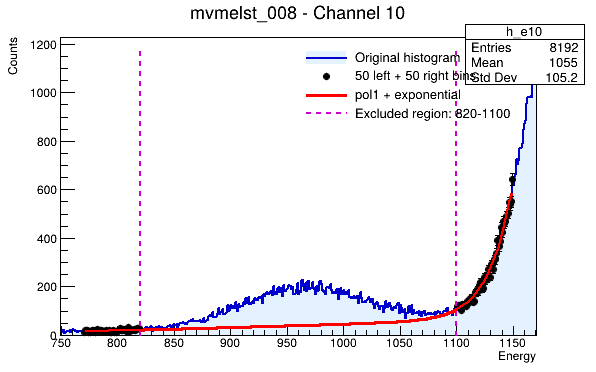

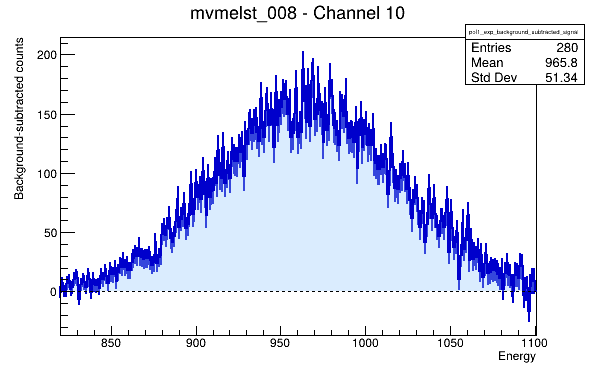

In [92]:
import ROOT
import math
from array import array

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------
signal_min = 820.0
signal_max = 1100.0

number_of_left_bins = 50
number_of_right_bins = 50

# Centering x improves numerical stability
x_reference = 0.5 * (signal_min + signal_max)

# ------------------------------------------------------------
# Find sideband bins
# ------------------------------------------------------------
nbins = hist.GetNbinsX()

left_candidates = [
    bin_number
    for bin_number in range(1, nbins + 1)
    if hist.GetBinCenter(bin_number) < signal_min
]

right_candidates = [
    bin_number
    for bin_number in range(1, nbins + 1)
    if hist.GetBinCenter(bin_number) > signal_max
]

if len(left_candidates) < number_of_left_bins:
    raise ValueError(
        f"Not enough bins below {signal_min}."
    )

if len(right_candidates) < number_of_right_bins:
    raise ValueError(
        f"Not enough bins above {signal_max}."
    )

# Last 20 bins before 800
left_bins = left_candidates[-number_of_left_bins:]

# First 30 bins after 1130
right_bins = right_candidates[:number_of_right_bins]

sideband_bins = left_bins + right_bins

print("Left sideband:")
print(
    f"  Number of bins = {len(left_bins)}\n"
    f"  Range = {hist.GetBinCenter(left_bins[0]):.2f} "
    f"to {hist.GetBinCenter(left_bins[-1]):.2f}"
)

print("\nRight sideband:")
print(
    f"  Number of bins = {len(right_bins)}\n"
    f"  Range = {hist.GetBinCenter(right_bins[0]):.2f} "
    f"to {hist.GetBinCenter(right_bins[-1]):.2f}"
)

# ------------------------------------------------------------
# Create a graph containing only the sideband bins
# ------------------------------------------------------------
x_values = []
y_values = []
x_errors = []
y_errors = []

for bin_number in sideband_bins:
    x = hist.GetBinCenter(bin_number)
    y = hist.GetBinContent(bin_number)

    x_error = 0.5 * hist.GetBinWidth(bin_number)
    y_error = hist.GetBinError(bin_number)

    if y_error <= 0:
        y_error = math.sqrt(max(abs(y), 1.0))

    x_values.append(x)
    y_values.append(y)
    x_errors.append(x_error)
    y_errors.append(y_error)

sideband_graph = ROOT.TGraphErrors(
    len(x_values),
    array("d", x_values),
    array("d", y_values),
    array("d", x_errors),
    array("d", y_errors)
)

sideband_graph.SetName("background_sideband_graph_pol1_exp")
sideband_graph.SetTitle("Background sidebands")
sideband_graph.SetMarkerStyle(20)
sideband_graph.SetMarkerSize(0.9)
sideband_graph.SetMarkerColor(ROOT.kBlack)
sideband_graph.SetLineColor(ROOT.kBlack)

# ------------------------------------------------------------
# Background model: pol1 + exponential
#
# B(x) = p0 + p1*dx + A*exp(k*dx)
#
# dx = x - x_reference
#
# [0] = polynomial intercept p0
# [1] = polynomial slope p1
# [2] = exponential amplitude A
# [3] = exponential slope k
# ------------------------------------------------------------
def background_model(x, par):
    dx = x[0] - x_reference

    linear_part = par[0] + par[1] * dx
    exponential_part = par[2] * math.exp(par[3] * dx)

    return linear_part + exponential_part


background_fit_min = hist.GetBinLowEdge(left_bins[0])

background_fit_max = (
    hist.GetBinLowEdge(right_bins[-1])
    + hist.GetBinWidth(right_bins[-1])
)

background_fit = ROOT.TF1(
    "pol1_plus_exponential_background",
    background_model,
    background_fit_min,
    background_fit_max,
    4
)

background_fit.SetParName(0, "Polynomial p0")
background_fit.SetParName(1, "Polynomial p1")
background_fit.SetParName(2, "Exponential amplitude")
background_fit.SetParName(3, "Exponential slope")

# ------------------------------------------------------------
# Initial estimates
# ------------------------------------------------------------
left_y_values = [
    hist.GetBinContent(bin_number)
    for bin_number in left_bins
]

right_y_values = [
    hist.GetBinContent(bin_number)
    for bin_number in right_bins
]

left_average = sum(left_y_values) / len(left_y_values)
right_average = sum(right_y_values) / len(right_y_values)

exponential_amplitude_guess = max(
    right_average - left_average,
    1.0
)

initial_parameters = [
    max(left_average, 0.0),        # p0
    0.0,                           # p1
    exponential_amplitude_guess,   # exponential amplitude
    0.005                          # exponential slope
]

for index, value in enumerate(initial_parameters):
    background_fit.SetParameter(index, value)

# Exponential amplitude must be nonnegative
background_fit.SetParLimits(
    2,
    0.0,
    max(10.0 * max(y_values), 1000.0)
)

# Limit exponential slope to prevent numerical divergence
background_fit.SetParLimits(
    3,
    -0.05,
    0.05
)

# ------------------------------------------------------------
# Fit the 50 selected sideband bins
# ------------------------------------------------------------
background_fit_result = sideband_graph.Fit(
    background_fit,
    "RS"
)

# ------------------------------------------------------------
# Select bins in the signal interval
# ------------------------------------------------------------
signal_bins = [
    bin_number
    for bin_number in range(1, nbins + 1)
    if (
        hist.GetBinCenter(bin_number) >= signal_min
        and hist.GetBinCenter(bin_number) <= signal_max
    )
]

if not signal_bins:
    raise ValueError(
        f"No histogram bins found between "
        f"{signal_min} and {signal_max}."
    )

first_signal_bin = signal_bins[0]
last_signal_bin = signal_bins[-1]

# ------------------------------------------------------------
# Create background and subtracted-signal histograms
# ------------------------------------------------------------
background_hist = hist.Clone(
    "estimated_pol1_exp_background_hist"
)
background_hist.Reset("ICES")

signal_hist = hist.Clone(
    "pol1_exp_background_subtracted_signal"
)
signal_hist.Reset("ICES")

observed_yield = 0.0
background_yield = 0.0
signal_yield = 0.0
data_variance = 0.0

for bin_number in signal_bins:
    x = hist.GetBinCenter(bin_number)

    observed_content = hist.GetBinContent(bin_number)
    observed_error = hist.GetBinError(bin_number)

    estimated_background = background_fit.Eval(x)

    background_subtracted_content = (
        observed_content - estimated_background
    )

    background_hist.SetBinContent(
        bin_number,
        estimated_background
    )

    signal_hist.SetBinContent(
        bin_number,
        background_subtracted_content
    )

    # Histogram uncertainty only
    signal_hist.SetBinError(
        bin_number,
        observed_error
    )

    observed_yield += observed_content
    background_yield += estimated_background
    signal_yield += background_subtracted_content
    data_variance += observed_error**2

data_only_signal_error = math.sqrt(data_variance)

# ------------------------------------------------------------
# Fit quality
# ------------------------------------------------------------
chi_square = background_fit.GetChisquare()
ndf = background_fit.GetNDF()

reduced_chi_square = (
    chi_square / ndf
    if ndf > 0
    else float("nan")
)

# ------------------------------------------------------------
# Draw original histogram and background fit
# ------------------------------------------------------------
canvas_background = ROOT.TCanvas(
    "canvas_pol1_exp_background",
    "pol1 plus exponential background",
    600,
    400
)

hist.SetLineColor(ROOT.kBlue + 1)
hist.SetLineWidth(2)
hist.SetFillColorAlpha(ROOT.kAzure - 9, 0.25)

display_min = (
    hist.GetBinLowEdge(left_bins[0]) - 20
)

display_max = (
    hist.GetBinLowEdge(right_bins[-1])
    + hist.GetBinWidth(right_bins[-1])
    + 20
)

hist.GetXaxis().SetRangeUser(
    display_min,
    display_max
)

hist.GetXaxis().SetTitle("Energy")
hist.GetYaxis().SetTitle("Counts")
hist.Draw("HIST")

background_fit.SetLineColor(ROOT.kRed)
background_fit.SetLineWidth(3)
background_fit.Draw("SAME")

sideband_graph.Draw("P SAME")

# Boundaries of excluded region
left_boundary = ROOT.TLine(
    signal_min,
    0,
    signal_min,
    hist.GetMaximum()
)

right_boundary = ROOT.TLine(
    signal_max,
    0,
    signal_max,
    hist.GetMaximum()
)

for line in [left_boundary, right_boundary]:
    line.SetLineColor(ROOT.kMagenta + 1)
    line.SetLineStyle(7)
    line.SetLineWidth(2)
    line.Draw("SAME")

legend_background = ROOT.TLegend(
    0.50,
    0.67,
    0.88,
    0.87
)

legend_background.SetBorderSize(0)
legend_background.SetFillStyle(0)

legend_background.AddEntry(
    hist,
    "Original histogram",
    "lf"
)

legend_background.AddEntry(
    sideband_graph,
    "50 left + 50 right bins",
    "p"
)

legend_background.AddEntry(
    background_fit,
    "pol1 + exponential",
    "l"
)

legend_background.AddEntry(
    left_boundary,
    "Excluded region: 820-1100",
    "l"
)

legend_background.Draw()
canvas_background.Draw()

# ------------------------------------------------------------
# Draw the background-subtracted signal
# ------------------------------------------------------------
canvas_signal = ROOT.TCanvas(
    "canvas_pol1_exp_subtracted_signal",
    "Background-subtracted signal",
    600,
    400
)

signal_hist.SetLineColor(ROOT.kBlue + 1)
signal_hist.SetLineWidth(2)
signal_hist.SetFillColorAlpha(ROOT.kAzure - 9, 0.35)

signal_hist.GetXaxis().SetRangeUser(
    signal_min,
    signal_max
)

signal_hist.GetXaxis().SetTitle("Energy")
signal_hist.GetYaxis().SetTitle(
    "Background-subtracted counts"
)

signal_hist.Draw("HIST E")

zero_line = ROOT.TLine(
    signal_min,
    0,
    signal_max,
    0
)

zero_line.SetLineColor(ROOT.kBlack)
zero_line.SetLineStyle(2)
zero_line.Draw("SAME")

canvas_signal.Draw()

# ------------------------------------------------------------
# Print results
# ------------------------------------------------------------
print("\n========== BACKGROUND FIT RESULTS ==========")

print("\nBackground parameters:")
print(
    f"  Polynomial p0 = "
    f"{background_fit.GetParameter(0):.6g} "
    f"± {background_fit.GetParError(0):.6g}"
)

print(
    f"  Polynomial p1 = "
    f"{background_fit.GetParameter(1):.6g} "
    f"± {background_fit.GetParError(1):.6g}"
)

print(
    f"  Exponential amplitude = "
    f"{background_fit.GetParameter(2):.6g} "
    f"± {background_fit.GetParError(2):.6g}"
)

print(
    f"  Exponential slope = "
    f"{background_fit.GetParameter(3):.6g} "
    f"± {background_fit.GetParError(3):.6g}"
)

print("\nBackground fit quality:")
print(f"  Chi-square     = {chi_square:.3f}")
print(f"  NDF            = {ndf}")
print(f"  Chi-square/NDF = {reduced_chi_square:.3f}")
print(f"  Fit status     = {int(background_fit_result)}")

print("\n========== YIELD FROM 800 TO 1130 ==========")

print(
    f"  First included bin center = "
    f"{hist.GetBinCenter(first_signal_bin):.3f}"
)

print(
    f"  Last included bin center  = "
    f"{hist.GetBinCenter(last_signal_bin):.3f}"
)

print(
    f"  Number of signal bins     = "
    f"{len(signal_bins)}"
)

print(
    f"\n  Observed histogram yield    = "
    f"{observed_yield:.2f}"
)

print(
    f"  Estimated background        = "
    f"{background_yield:.2f}"
)

print(
    f"  Background-subtracted yield = "
    f"{signal_yield:.2f}"
)

print(
    f"  Data-only statistical error = "
    f"{data_only_signal_error:.2f}"
)

if int(background_fit_result) != 0:
    print(
        "\nWarning: the background fit did not converge."
    )